# Analiza wyjasnialosci - XGBoost tuned

Notebook wykonuje analize decyzji modelu `XGBoost_tuned` z uzyciem:
- SHAP (globalna i lokalna wyjasnialosc),
- LIME (lokalna wyjasnialosc predykcji).

Zakladam, ze model zostal juz wytrenowany i zapisany w `artifacts/models/XGBoost_tuned.joblib`.


In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import shap
from lime.lime_tabular import LimeTabularExplainer


/home/dron/Projekty/LublinRCN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_path = Path('artifacts/models/XGBoost_tuned.joblib')
if not model_path.exists():
    raise FileNotFoundError(f'Nie znaleziono modelu: {model_path}')

data_candidates = [
    Path('data/final_data.parquet'),
    Path('data/clean_data.parquet'),
]

data_path = None
for p in data_candidates:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('Nie znaleziono pliku data/final_data.parquet ani data/clean_data.parquet')

target_col = 'tran_cena_brutto'
top10_features = [
    'lok_pow_uzyt',
    'Ulica',
    'coord_y',
    'coord_x',
    'nier_pow_gruntu',
    'dzielnica',
    'tran_rodzaj_trans',
    'tran_rodzaj_rynku',
    'lok_liczba_izb',
    'tran_sprzedajacy',
]

pipe = joblib.load(model_path)
df = pd.read_parquet(data_path)

required_cols = top10_features + [target_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Brakuje kolumn w danych: {missing_cols}')

analysis_df = df[required_cols].dropna().copy()
X = analysis_df[top10_features]
y = analysis_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print('Model:', model_path)
print('Dane :', data_path)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)


Model: artifacts/models/XGBoost_tuned.joblib
Dane : data/final_data.parquet
X_train: (3317, 10) | X_test: (830, 10)


In [3]:
preprocessor = pipe.named_steps['preprocessor']
model = pipe.named_steps['model']

X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

if hasattr(X_train_trans, 'toarray'):
    X_train_trans = X_train_trans.toarray()
if hasattr(X_test_trans, 'toarray'):
    X_test_trans = X_test_trans.toarray()

print('Transform shape train:', X_train_trans.shape)
print('Transform shape test :', X_test_trans.shape)
print('Liczba cech po preprocessingu:', len(feature_names))


Transform shape train: (3317, 428)
Transform shape test : (830, 428)
Liczba cech po preprocessingu: 428


## SHAP - globalna wyjasnialosc


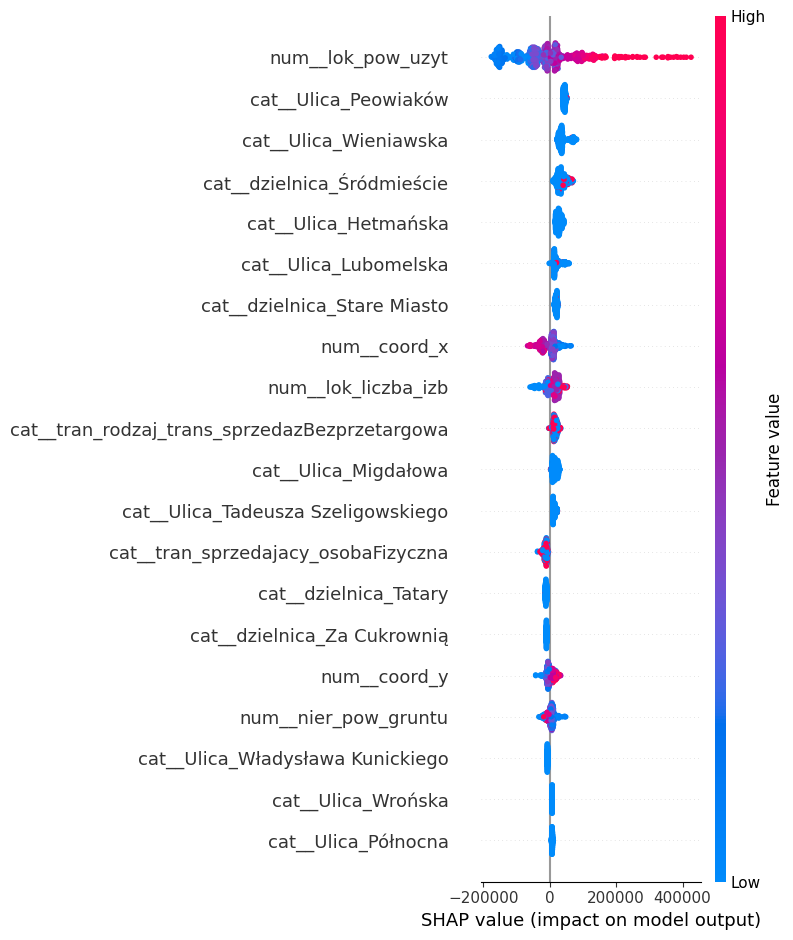

,feature,mean_abs_shap
0,num__lok_pow_uzyt,76149.335938
1,cat__Ulica_Peowiaków,44137.554688
2,cat__Ulica_Wieniawska,38164.695312
3,cat__dzielnica_Śródmieście,34755.039062
4,cat__Ulica_Hetmańska,26960.828125
5,cat__Ulica_Lubomelska,19827.029297
6,cat__dzielnica_Stare Miasto,19067.250000
7,num__coord_x,16750.507812
8,num__lok_liczba_izb,16322.803711
9,cat__tran_rodzaj_trans_sprzedazBezprzetargowa,15914.663086


In [4]:
rng = np.random.RandomState(42)
sample_size = min(1000, X_test_trans.shape[0])
sample_idx = rng.choice(X_test_trans.shape[0], size=sample_size, replace=False)
X_shap = X_test_trans[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

display(shap_importance_df.head(20))


## SHAP - lokalna wyjasnialosc jednej predykcji


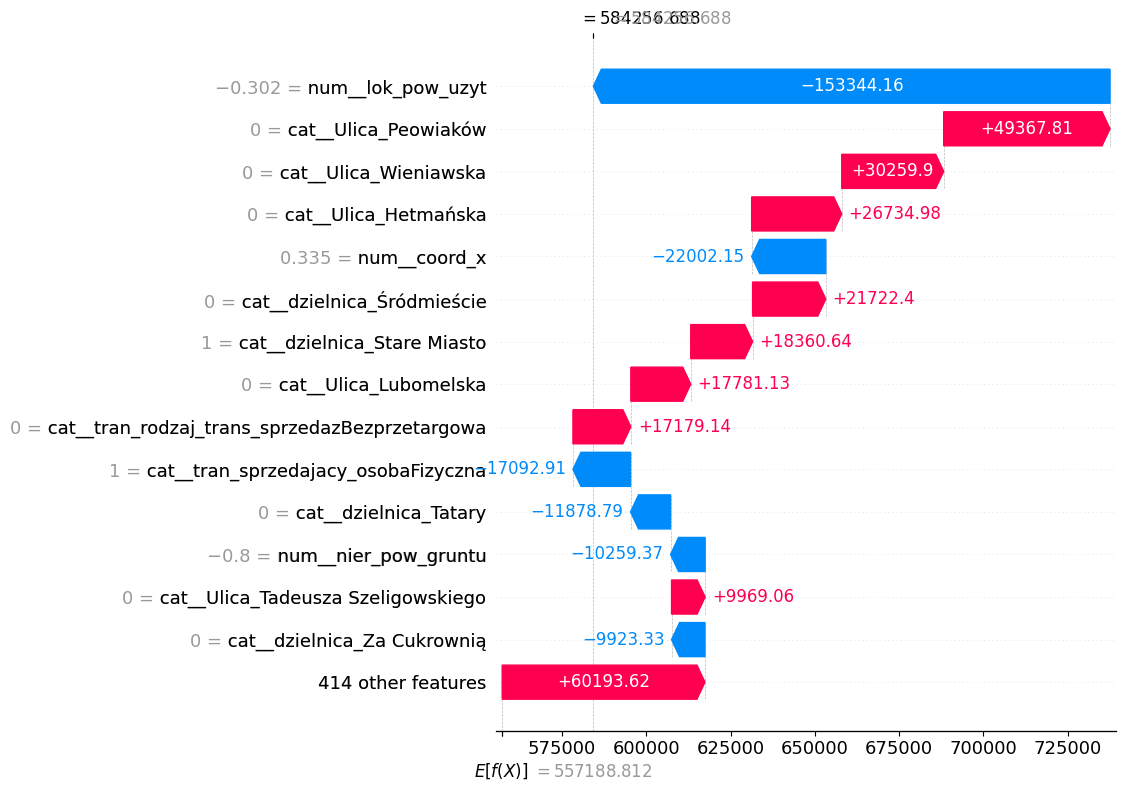

In [5]:
obs_idx = 0
base_value = explainer.expected_value
if isinstance(base_value, np.ndarray):
    base_value = float(np.ravel(base_value)[0])

single_exp = shap.Explanation(
    values=shap_values[obs_idx],
    base_values=base_value,
    data=X_shap[obs_idx],
    feature_names=feature_names,
)

shap.plots.waterfall(single_exp, max_display=15)


## LIME - lokalna wyjasnialosc jednej predykcji


,feature,weight
0,num__lok_pow_uzyt > 0.10,328069.584587
1,cat__Ulica_Gustawa Morcinka <= 0.00,-105351.756452
2,cat__Ulica_Wojenna <= 0.00,94848.375199
3,cat__Ulica_Skrzatów <= 0.00,91845.700077
4,cat__Ulica_Romantyczna <= 0.00,-89671.832003
5,cat__Ulica_Bociania <= 0.00,84958.176411
6,cat__Ulica_Żmigród <= 0.00,75708.055872
7,cat__Ulica_Kazimierza Wielkiego <= 0.00,72508.818007
8,cat__Ulica_Zuchów <= 0.00,71842.836591
9,cat__Ulica_Kaprysowa <= 0.00,68891.623155


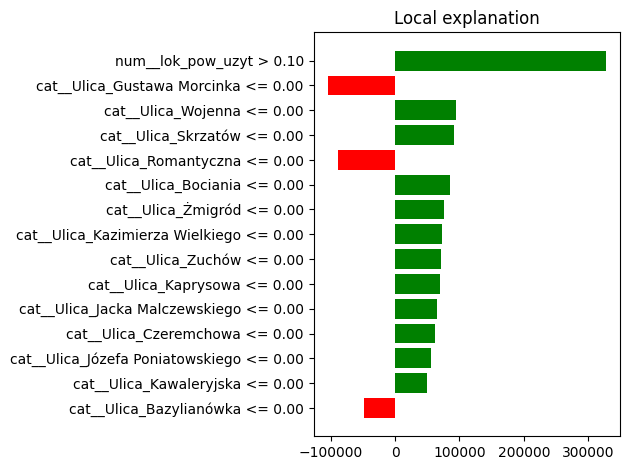

In [6]:
lime_train_size = min(2000, X_train_trans.shape[0])
lime_train_idx = rng.choice(X_train_trans.shape[0], size=lime_train_size, replace=False)
lime_train = X_train_trans[lime_train_idx]

lime_explainer = LimeTabularExplainer(
    training_data=lime_train,
    feature_names=list(feature_names),
    mode='regression',
    discretize_continuous=True,
    random_state=42,
)

def predict_transformed(x):
    return model.predict(x)

lime_instance_idx = 0
lime_instance = X_test_trans[lime_instance_idx]
lime_exp = lime_explainer.explain_instance(
    data_row=lime_instance,
    predict_fn=predict_transformed,
    num_features=15,
)

lime_df = pd.DataFrame(lime_exp.as_list(), columns=['feature', 'weight'])
display(lime_df)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()


In [7]:
out_dir = Path('artifacts/explainability')
out_dir.mkdir(parents=True, exist_ok=True)

shap_importance_path = out_dir / 'xgboost_tuned_shap_importance.csv'
lime_path = out_dir / 'xgboost_tuned_lime_instance_0.csv'
lime_html_path = out_dir / 'xgboost_tuned_lime_instance_0.html'

shap_importance_df.to_csv(shap_importance_path, index=False)
lime_df.to_csv(lime_path, index=False)
lime_exp.save_to_file(str(lime_html_path))

print('Zapisano:')
print('-', shap_importance_path)
print('-', lime_path)
print('-', lime_html_path)


Zapisano:
- artifacts/explainability/xgboost_tuned_shap_importance.csv
- artifacts/explainability/xgboost_tuned_lime_instance_0.csv
- artifacts/explainability/xgboost_tuned_lime_instance_0.html
